# Chemprop v2 — Experiment 0: Negative Control (No Stereochemistry)

This notebook establishes the negative control baseline for the Chemprop chirality
classification experiments. All stereochemical information is stripped from the
molecular graphs via `ignore_stereo=True`, making both enantiomers of each compound
identical from the MPNN's perspective.

**Expected result:** all three targets (`R/S_class`, `@/@@_class`, `F/L_class`)
should be predicted at chance i.e., ~50% AUROC, ~50% accuracy, MCC ≈ 0.

**Conditions in this notebook:**

| Condition | Type | Description |
|---|---|---|
| `exp_0_neg_control_no_stereo_singletask` | Single-task | Independent model per target, stereo stripped |
| `exp_0_neg_control_no_stereo_multitask` | Multi-task | Joint model for all 3 targets, stereo stripped |

**Total fits:** 1 condition × 3 targets × 5 folds (singletask) + 5 folds (multitask) = 20

Part of series: `3_RF_morgan_count.ipynb` → **`4_chemprop_exp_0.ipynb`** → `4_chemprop_exp_1.ipynb`

## Imports

**On warning filters.** Previous draft used `warnings.filterwarnings('ignore', category=UserWarning)`, but this can hide useful warnings e.g., if a shuffled training dataloader is accidentally used for prediction, Lightning warns via `PossibleUserWarning`, whose MRO is
`(PossibleUserWarning, UserWarning, Warning, ...)`, so blanket-ignoring `UserWarning` silences it. 
This notebook now filters only four specific messages, each verified as benign:
- dataloader worker counts
- a torch pytree deprecation
- Lightning declining to YAML-dump the `metrics` parameter
- MPS nondeterminism (see Configuration)

In [1]:
import gc
import re
import time
import warnings
from pathlib import Path

# use specific filters instead generic `filterwarnings('ignore', category=UserWarning)`.
# last entry is MPS non-determinism (expected, not a bug).
for _msg in (
    '.*does not have many workers.*',
    '.*isinstance\\(treespec, LeafSpec\\).*',
    '.*Skipping .metrics. parameter.*',
    '.*does not have a deterministic implementation.*',
):
    warnings.filterwarnings('ignore', message=_msg)

import numpy as np
import pandas as pd
import torch

from lightning import pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from sklearn.metrics import (
    roc_auc_score,
    matthews_corrcoef,
    accuracy_score,
    f1_score,
    average_precision_score,
)

from chemprop import data, featurizers, models, nn

## Configuration

`MONITOR` / `MONITOR_MODE` are the single source of truth for both `EarlyStopping` and
`ModelCheckpoint`. These two callbacks should track the same metric; otherwise, training would stop on one notion of "best" while a different epoch's weights get saved.
`EarlyStopping` asks "is training still making meaningful progress?" and needs a noise floor of `MIN_DELTA`. 
ModelCheckpoint asks "which epoch had the best monitored value?" within the training window with no noise floor.

`val_loss` (BCE, logged by chemprop from `self.metrics[-1]`) is monitored rather than
`val/roc` because:

* BCE is a proper scoring rule, capturing ranking and calibration; AUROC is invariant to
  any monotone rescaling of the scores and so cannot see calibration at all.
* `ModelCheckpoint` compares strictly (`torch.gt` for `mode='max'`), so once AUROC saturates, it
   never replaces the saved checkpoint and selection freezes on an early, uncalibrated epoch.
* For the multitask model `val/roc` is a single AUROC **pooled across all three targets**
  (`ClassificationMixin.update` flattens the task dimension), so it is dominated by whichever
  target is already solved. **`BCELoss` carries per-task weights and reduces to a task-weighted
  mean, so solved tasks fade and unsolved ones dominate.**


Details about the epoch controls:
* `MIN_EPOCHS` forces the training loop to continue, but it does **not** constrain which
epoch is checkpointed. `ModelCheckpoint` has no awareness of it, so `best_epoch` can be
smaller than `MIN_EPOCHS`.
* `MIN_DELTA` is the minimum `val_loss` improvement that resets early-stopping patience. `ModelCheckpoint`
    ignores it and saves on *any* improvement, so `best_epoch` can also be *later* than the epoch
    that last reset patience.
  - `MIN_DELTA` matters in this notebook since the negative control cannot learn, so `val_loss` sits near
ln(2) from the first epoch and only noise moves it. At `MIN_DELTA = 0.0` those noise-driven
"improvements" keep resetting patience and push fits toward `MAX_EPOCHS` for no reason.

**Decision threshold.** Same in all notebooks: tuned on validation but metrics reported at both the default 0.5 and the tuned value. 

This notebook is a negative control that ensures the data was split correctly.
`2_create_data_splits.ipynb` splits on *pair* indices and `validate_pairs` asserts both
enantiomers land in the same split. Stripping stereochemistry collapses each pair to one graph
carrying both labels, so **any** threshold labels both members identically — one right, one
wrong. Hence TP = FN, TN = FP, and **MCC = 0 at every threshold on every split**;
`tune_threshold` ties everywhere and returns 0.5; AUROC is pinned at 0.5000 (every pair is a
tie); and `best_score ≈ ln 2 = 0.693`. `MIN_DELTA` matters most here — with nothing to learn,
`val_loss` sits at ln(2) and only noise moves it, so `MIN_DELTA = 0.0` would let noise reset
patience and push fits toward `MAX_EPOCHS`.

In practice, the tuned threshold lands near 0.5. Identical
molecular sgraphs *should* give identical probabilities, and most validation pairs do — but a few
differ by ~`1e-7`, because batched `scatter_reduce` on MPS is not deterministic and a
molecule's accumulation order depends on its position in the batch. 
`tune_threshold` places the cutoff inside that gap and earns ~0.01 validation MCC from 
pure float noise. With n_val = 190, the threshold is overfitting and the threshold should be trusted.
When the results are compared across notebook experiments, we use the default threshold of 0.5.


Chemprop's MoleculeDataset uses PyTorch's DataLoader object [https://github.com/chemprop/chemprop/blob/main/chemprop/data/datasets.py#L191](https://github.com/chemprop/chemprop/blob/main/chemprop/data/datasets.py#L191).
`num_workers=0` loads data sequentially in the main process. Setting `num_workers=1` forces Python to spawn a separate background process, serialize the data, transfer it across shared memory, and deserialize it back. This is not efficient given the size of the dataset here.

In [ ]:
INPUT_PATH  = 'data/class_all.csv'
FOLDS_PATH  = 'data/cmrt_folds.npz'
NUM_WORKERS = 0      # set >0 if multiprocessing is available

# ── Run identity: keeps checkpoints/logs/labels from colliding across re-runs ──
RUN_TAG   = 'exp0_no_stereo'
CKPT_ROOT = Path('checkpoints') / RUN_TAG
LOG_ROOT  = Path('logs') / RUN_TAG
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_ROOT.mkdir(parents=True, exist_ok=True)

# ── Early stopping + checkpointing (single source of truth) ───────────────────
MONITOR      = 'val_loss'   # BCE; see above for why not 'val/roc'
MONITOR_MODE = 'min'
MIN_EPOCHS   = 10           # floor before EarlyStopping is allowed to end the run.
                            # Does NOT constrain best_epoch, which can be smaller.
MAX_EPOCHS   = 75           # upper bound
PATIENCE     = 10
MIN_DELTA    = 1e-5         # min val_loss improvement that resets patience

BATCH_SIZE = 64
SEED       = 42

pl.seed_everything(SEED, workers=True)

print(f'run_tag={RUN_TAG}  monitor={MONITOR} ({MONITOR_MODE})  min_epochs={MIN_EPOCHS}  '
      f'max_epochs={MAX_EPOCHS}  patience={PATIENCE}  min_delta={MIN_DELTA}')

Seed set to 42


run_tag=exp0_no_stereo  monitor=val_loss (min)  min_epochs=10  max_epochs=75  patience=10  min_delta=1e-05


## Load data and splits

In [3]:
df = pd.read_csv(INPUT_PATH, index_col=0)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3858, 6)


,SMILES,SMILES_opp,TR/TE,F/L_class,@/@@_class,R/S_class
0,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,TE,F,@,S
1,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,TE,L,@@,R
2,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,TE,F,@,S
3,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,TE,L,@@,R
4,C=C(C(C)=O)[C@@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,C=C(C(C)=O)[C@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,TE,F,@@,R


In [4]:
def load_folds(path: str) -> list[dict[str, np.ndarray]]:
    """
    Load pre-computed splits from a .npz file.

    Args:
        path: Path to .npz file saved by save_folds() in notebook 2.

    Returns:
        List of dicts with keys 'train', 'val', 'test' as numpy arrays
        of molecule-level integer indices into the full dataset.
    """
    archive = np.load(path)
    fold_indices = sorted(set(
        int(k.split('_')[0].replace('fold', '')) for k in archive.files))
    return [
        {
            'train': archive[f'fold{i}_train'],
            'val':   archive[f'fold{i}_val'],
            'test':  archive[f'fold{i}_test'],
        }
        for i in fold_indices
    ]

In [5]:
mol_folds = load_folds(FOLDS_PATH)
print(f'Loaded {len(mol_folds)} folds')
for i, fold in enumerate(mol_folds):
    n_tr = len(fold['train'])
    n_v  = len(fold['val'])
    n_te = len(fold['test'])
    print(f'  Fold {i}: train={n_tr:,}  val={n_v:,}  test={n_te:,}')

Loaded 5 folds
  Fold 0: train=3,478  val=190  test=190
  Fold 1: train=3,478  val=190  test=190
  Fold 2: train=3,478  val=190  test=190
  Fold 3: train=3,478  val=190  test=190
  Fold 4: train=3,478  val=190  test=190


## Target variables and label encoding

All three targets are binary and perfectly balanced (50/50). Chance baseline: 50%.

In [6]:
TARGET_LABEL_MAPS = {
    'R/S_class':  {'R': 0, 'S': 1},
    '@/@@_class': {'@': 0, '@@': 1},
    'F/L_class':  {'F': 0, 'L': 1},
}
SINGLE_TARGETS = list(TARGET_LABEL_MAPS.keys())

for col, lmap in TARGET_LABEL_MAPS.items():
    df[f'label_{col}'] = df[col].map(lmap)

print('Class distributions (all should be 50/50):')
for col in SINGLE_TARGETS:
    vc = df[f'label_{col}'].value_counts(normalize=True)
    print(f'  {col}: {vc.to_dict()}')

Class distributions (all should be 50/50):
  R/S_class: {1: 0.5, 0: 0.5}
  @/@@_class: {0: 0.5, 1: 0.5}
  F/L_class: {0: 0.5, 1: 0.5}


## Featurizer: negative control — stereochemistry stripped

`SimpleMoleculeMolGraphFeaturizer` is used in both conditions, but `ignore_stereo=True`
is passed to `MoleculeDatapoint.from_smi()` for the negative control.

**What `ignore_stereo=True` does:** before building the RDKit mol object, all `@/@@`
annotations are stripped from the SMILES string. The resulting molecular graphs are
*identical for both enantiomers* — the MPNN has no information to distinguish them.

**Expected result:** all three targets should be predicted at chance (~50% AUROC,
~50% accuracy, MCC ≈ 0). Any model that scores above chance on this condition has
found a confound, not a stereochemical signal.

**Multi-task negative control (`exp_0_neg_control_no_stereo_multitask`):** the same
stereo-stripped datapoints are used, with `BinaryClassificationFFN(n_tasks=3)`. This
confirms the null result holds when all three targets are predicted jointly.

In [7]:
_feat_inspect = featurizers.SimpleMoleculeMolGraphFeaturizer()
from rdkit import Chem
_mol = Chem.MolFromSmiles('Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2')
_graph = _feat_inspect(_mol)
print(f'Atom feature dim: {_graph.V.shape[1]}')
print(f'Bond feature dim: {_graph.E.shape[1]}')
print('ChiralTag is a one-hot feature within the atom feature vector.')
print('Values: UNSPECIFIED=0, CW(@@)=1, CCW(@)=2')
print('With ignore_stereo=True this slot is always UNSPECIFIED for every atom.')

Atom feature dim: 72
Bond feature dim: 14
ChiralTag is a one-hot feature within the atom feature vector.
Values: UNSPECIFIED=0, CW(@@)=1, CCW(@)=2
With ignore_stereo=True this slot is always UNSPECIFIED for every atom.


In [8]:
# ignore_stereo=True: strips all @/@@ annotations before graph construction
# Both enantiomers produce the identical molecular graph — the negative control
all_data_no_stereo = [
    data.MoleculeDatapoint.from_smi(smi, ignore_stereo=True)
    for smi in df['SMILES']
]

print(f'Built {len(all_data_no_stereo):,} no-stereo datapoints (negative control)')

Built 3,858 no-stereo datapoints (negative control)


## Model and trainer builder functions

### Message Passing
A `Message passing` constructs molecular graphs using message passing to learn node-level hidden representations.

Options are `mp = nn.BondMessagePassing()` or `mp = nn.AtomMessagePassing()`

### Aggregation
An `Aggregation` constructs a graph-level representation from the set of
node-level representations after message passing. The permutation-invariant mean
is the standard Chemprop aggregation and is precisely what limits chirality signal
survival.

Available options can be found in ` nn.agg.AggregationRegistry` https://github.com/chemprop/chemprop/blob/main/chemprop/nn/agg.py#L106
- `agg = nn.MeanAggregation()`
- `agg = nn.SumAggregation()`
- `agg = nn.NormAggregation()`  by default, it divides the sum by 100

### Feed-Forward Network (FFN)

A `FFN` takes the aggregated representations and make target predictions.

Available options can be found in `nn.PredictorRegistry`.

For regression:
- `ffn = nn.RegressionFFN()`
- `ffn = nn.MveFFN()`
- `ffn = nn.EvidentialFFN()`

For classification:
- `ffn = nn.BinaryClassificationFFN()`
- `ffn = nn.BinaryDirichletFFN()`
- `ffn = nn.MulticlassClassificationFFN()`  input molecule can only belong to 1 of the n targets 
- `ffn = nn.MulticlassDirichletFFN()`

For spectral:
- `ffn = nn.SpectralFFN()` # will be available in future version


`nn.BinaryClassificationFFN(n_tasks=1)` for single-task; `n_tasks=3` for multi-task.
Both use BCELoss internally and apply sigmoid to produce per-task probabilities.

### Metrics

AUROC / AUPRC / Accuracy / F1 / MCC. `BinaryMCCMetric` is included so MCC is logged per
epoch (`val/binary-mcc`) for the convergence plots. Chemprop appends `criterion.clone()` to
`metrics` automatically, and that is what gets logged as `val_loss`.

> Use `BinaryMCCMetric`, not `BinaryMCCLoss`: the former is `higher_is_better=True`, the
> latter `False`, so mixing them up silently inverts any selection based on it.
>
> These three logged "threshold" metrics do not share semantics. `val/accuracy` and
> `val/f1` are thresholded at 0.5 by torchmetrics, but `val/binary-mcc` is **not
> thresholded at all** — chemprop's `BinaryMCCMetric` accumulates soft confusion counts
> straight from the probabilities, so it responds to confidence as well as ranking.


In [ ]:
def build_mpnn(n_tasks: int = 1) -> models.MPNN:
    """
    Build a fresh Chemprop v2 MPNN for binary classification.

    A new model is instantiated for every (condition, target, fold) to
    ensure no weight sharing across runs.

    For the BinaryClassificationFFN, n_targets is hardcoded to 1 and the default loss is BCELoss
    https://github.com/chemprop/chemprop/blob/7033cac6ebc1a66f885705c7fa3e2cb960f96e49/chemprop/nn/predictors.py#L236

    Passing n_tasks=3 means the output dimension becomes a tensor of shape (batch_size, 3).
    A .sigmoid() activation is applied to the entire tensor so each of the 3 targets is evaluated
    independently and gets its own distinct probability between 0 and 1.

    Args:
        n_tasks: Number of binary classification outputs. 1 for single-task;
            3 for the multi-task condition predicting all targets jointly.

    Returns:
        Configured chemprop.models.MPNN ready for training.
    """
    mp  = nn.BondMessagePassing()
    agg = nn.MeanAggregation()
    ffn = nn.BinaryClassificationFFN(n_tasks=n_tasks)  
    metric_list = [
        nn.metrics.BinaryAUROC(),       # val/roc
        nn.metrics.BinaryAUPRC(),       # val/prc
        nn.metrics.BinaryAccuracy(),    # val/accuracy   (at fixed 0.5)
        nn.metrics.BinaryF1Score(),     # val/f1         (at fixed 0.5)
        nn.metrics.BinaryMCCMetric(),   # val/binary-mcc (SOFT, not thresholded)
    ]
    # MPNN appends criterion.clone() to metrics -> logged as val_loss
    return models.MPNN(mp, agg, ffn, batch_norm=False, metrics=metric_list)


def run_name_for(condition_name: str, target_col: str, fold_idx: int) -> str:
    """Filesystem-safe identifier for one fit."""
    return f"{condition_name}_{target_col.replace('/', '_')}_fold{fold_idx}"


def build_trainer(fold_idx: int, condition_name: str, target_col: str) -> pl.Trainer:
    """
    Build a Lightning Trainer with EarlyStopping, ModelCheckpoint, and a CSVLogger.

    EarlyStopping and ModelCheckpoint track the same metric (MONITOR / MONITOR_MODE). 
    If they disagree, training stops on one definition of "best" while a
    different epoch's weights are the ones saved and later evaluated.

    min_epochs gates the loop's exit condition: FitLoop.done only honors an early-stop
    request once `epoch_progress.current.processed >= min_epochs`. It does not reset
    EarlyStopping's wait_count, so training ends as soon as the floor is met.

    auto_insert_metric_name=False plus an explicit `epoch={epoch}` in the filename lets us
    parse the winning epoch back out of best_model_path afterwards.

    Args:
        fold_idx: Current fold number (checkpoint/log naming).
        condition_name: Featurization condition (checkpoint/log naming).
        target_col: Target being predicted (checkpoint/log naming).

    Returns:
        Configured pl.Trainer.
    """
    run_name = run_name_for(condition_name, target_col, fold_idx)

    early_stop = EarlyStopping(
        monitor=MONITOR,
        mode=MONITOR_MODE,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        verbose=False,
    )
    checkpointing = ModelCheckpoint(
        dirpath=CKPT_ROOT,
        filename=f'{run_name}_best-epoch={{epoch}}',
        monitor=MONITOR,
        mode=MONITOR_MODE,
        save_top_k=1,
        auto_insert_metric_name=False,
        verbose=False,
    )

    return pl.Trainer(
        logger=CSVLogger(LOG_ROOT, name=run_name),
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator='auto',
        devices=1,
        min_epochs=MIN_EPOCHS,
        max_epochs=MAX_EPOCHS,
        log_every_n_steps=10,   # training set has ~3500 / 64 batch size = 55 batches per epoch
        deterministic='warn',   # 'warn' not True: some scatter ops lack deterministic kernels
        callbacks=[early_stop, checkpointing],
    )


def fit_provenance(trainer: pl.Trainer) -> dict:
    """
    Record what actually happened during a fit.

    `trainer.current_epoch` alone is misleading: it is the number of epochs run, not the
    epoch whose weights were checkpointed and are about to be evaluated. Under
    min_epochs those differ, and under a saturated monitor they can differ wildly.
    """
    ckpt = trainer.checkpoint_callback
    es = trainer.early_stopping_callback
    m = re.search(r'epoch=(\d+)', ckpt.best_model_path or '')
    return {
        'epochs_run':   trainer.current_epoch,
        'best_epoch':   int(m.group(1)) if m else np.nan,
        'best_score':   float(ckpt.best_model_score) if ckpt.best_model_score is not None else np.nan,
        'es_triggered': bool(es.stopped_epoch > 0) if es is not None else False,
        'monitor':      MONITOR,
        'min_epochs':   MIN_EPOCHS,
        'max_epochs':   MAX_EPOCHS,
        'patience':     PATIENCE,
        'min_delta':    MIN_DELTA,
        'run_tag':      RUN_TAG,
    }


def read_curves(trainer: pl.Trainer, condition_name: str, target_col: str,
                fold_idx: int) -> pd.DataFrame:
    """
    Read this fit's per-epoch metrics from the CSVLogger and return a tidy frame.

    Lightning writes train- and val-side metrics on SEPARATE rows (each with NaN in the
    other columns), so collapse by epoch before use.
    """
    path = Path(trainer.logger.log_dir) / 'metrics.csv'
    if not path.exists():
        return pd.DataFrame()
    raw = pd.read_csv(path)
    curves = raw.groupby('epoch', as_index=False).mean(numeric_only=True)
    curves.insert(0, 'featurization', condition_name)
    curves.insert(1, 'target', target_col)
    curves.insert(2, 'fold', fold_idx)
    return curves

## Prediction and scoring helpers

Identical to exp_1 / exp_2 so metric definitions match by construction:

1. `predict_probs` — loads the best checkpoint and returns probabilities **in dataset
   order**. Requires a `shuffle=False` loader; an `assert` guards the row count.
2. `tune_threshold` — picks the threshold maximizing MCC on the **validation** split. Here it
   is expected to return exactly 0.5 (see Configuration for why).
3. `score_probs` — AUROC/AUPRC (threshold-free) plus MCC/Accuracy/F1 at a given threshold.
4. `score_both` — runs step 3 twice, at 0.5 and at the tuned threshold, so the results CSV
   carries both column sets. Identical to exp_1 / exp_2.

Because `ModelCheckpoint` builds a unique filename from the current loop variables, the
Trainer resolves `ckpt_path='best'` against the `ModelCheckpoint` instance active during its
own `fit()` call. It has no awareness of checkpoints written by earlier iterations.

`weights_only=False` is required to unpickle chemprop's custom metric objects from the
Lightning checkpoint.

In [ ]:
def predict_probs(trainer: pl.Trainer, mpnn: models.MPNN, loader) -> np.ndarray:
    """
    Predict with the best checkpoint and return probabilities in dataset order.

    The loader must have shuffle=False. trainer.predict() returns batches in iteration
    order, so a shuffled loader yields a random permutation that no longer lines up with
    the label array -- which is what made train-split metrics collapse to ~0.50 AUROC in
    the earlier notebooks.

    Returns:
        (n,) array for single-task, (n, n_tasks) for multi-task.
    """
    preds = trainer.predict(mpnn, loader, ckpt_path='best', weights_only=False)
    probs = torch.cat(preds).numpy()
    if probs.ndim > 1 and probs.shape[1] == 1:
        probs = probs[:, 0]
    return probs


def tune_threshold(y_true: np.ndarray, probs: np.ndarray) -> float:
    """
    Choose the decision threshold maximizing MCC on the given (validation) split.

    MCC is chosen because it uses all four confusion-matrix cells and is symmetric under
    swapping the class labels — appropriate here, where neither R nor S (nor F nor L) is a
    privileged "positive" class. It is also the metric reported in the results CSV: the
    tuning objective should match the reported decision metric.

    Candidate construction, `np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0]`:
      * `grid` is the sorted unique predicted probabilities. Any threshold strictly between
        two adjacent values produces the identical set of hard predictions, so the midpoints
        enumerate every distinct classification this model can produce — the full candidate
        space, no finer grid needed.
      * 0.5 is prepended so the conventional threshold is always considered. Because
        `np.argmax` returns the FIRST maximum, 0.5 wins any tie. MCC as a function of the
        threshold is a step function with many ties at small n, so this makes 0.5 the
        default and only departs from it when some other threshold is strictly better.

    Caveat: with n_val = 190 this is a noisy estimate. Tuning corrects miscalibration but
    adds variance; on perfectly balanced data a well-calibrated model should already be
    optimal at 0.5.
    """
    grid = np.unique(probs)
    cands = np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0] if grid.size > 1 else np.array([0.5])
    scores = [matthews_corrcoef(y_true, (probs > t).astype(int)) for t in cands]
    return float(cands[int(np.argmax(scores))])


def score_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Compute all metrics for one split at a fixed threshold.

    AUROC/AUPRC are threshold-free and are the primary metrics. MCC/Accuracy/F1 depend on
    `threshold` and are secondary.
    """
    assert len(probs) == len(y_true), (
        f'prediction/label length mismatch: {len(probs)} vs {len(y_true)}. '
        'Check that the loader used shuffle=False and that drop_last did not fire.'
    )
    preds_bin = (probs > threshold).astype(int)
    return {
        'AUROC':     roc_auc_score(y_true, probs),
        'AUPRC':     average_precision_score(y_true, probs),
        'MCC':       matthews_corrcoef(y_true, preds_bin),
        'Accuracy':  accuracy_score(y_true, preds_bin),
        'F1':        f1_score(y_true, preds_bin),
        'threshold': threshold,
    }


def score_both(y_true: np.ndarray, probs: np.ndarray, tuned_threshold: float) -> dict:
    """
    Score one split twice: at the fixed 0.5 cutoff and at the validation-tuned threshold.

    Recording both removes a comparability problem instead of trading one for another:

      * The plain `MCC` / `Accuracy` / `F1` columns use 0.5, which is what
        `3_RF_morgan_count.ipynb` effectively uses via `RandomForestClassifier.predict()`
        (argmax over `predict_proba` is a 0.5 cutoff for binary). Those columns are
        directly comparable across model families.
      * The `*_tuned` columns use the per-(target, fold) threshold fitted on validation, and
        show what calibration was costing at a fixed cutoff.

    AUROC and AUPRC are threshold-free and identical under both, so they are not duplicated.
    Costs nothing extra at runtime — the same probabilities are scored twice.
    """
    m = score_probs(y_true, probs, 0.5)                      # -> 'threshold' == 0.5
    t = score_probs(y_true, probs, tuned_threshold)
    m.update({f'{k}_tuned': t[k] for k in ('MCC', 'Accuracy', 'F1')})
    m['threshold_tuned'] = tuned_threshold
    return m

## Single-task training loop — Exp 0

One condition × 3 targets × 5 folds = **15 total fits**

The `val` split drives EarlyStopping and is not used for evaluation.
Train, val, and test scores are all appended to `all_results` for completeness,
but only test scores are printed during the loop.

In [11]:
# Only one condition in this notebook: the negative control
SINGLE_TASK_CONDITIONS = {
    'exp_0_neg_control_no_stereo_singletask': all_data_no_stereo,
}

# Total single-task fits: 1 condition x 3 targets x 5 folds = 15
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

all_results = []
all_curves  = []
all_preds   = []

for condition_name, all_dpoints in SINGLE_TASK_CONDITIONS.items():
    CONDITION_START = time.time()
    print(f"\n{'#'*70}")
    print(f'Condition: {condition_name}')
    print('  Negative control: stereo stripped, enantiomers are identical graphs')
    print('  Expected: all targets at chance (~50% accuracy, AUROC ~0.50)')
    print(f"{'#'*70}")

    for target_col in SINGLE_TARGETS:
        label_col = f'label_{target_col}'
        print(f"\n  Target: {target_col}\n  {'-'*60}")

        for fold_idx, fold in enumerate(mol_folds):
            FOLD_START = time.time()
            # Re-seed per fit so results do not depend on cell execution order.
            pl.seed_everything(SEED + fold_idx, workers=True)

            tr_pts = [all_dpoints[i] for i in fold['train']]
            va_pts = [all_dpoints[i] for i in fold['val']]
            te_pts = [all_dpoints[i] for i in fold['test']]

            y_train = df[label_col].iloc[fold['train']].values.reshape(-1, 1)
            y_val   = df[label_col].iloc[fold['val']].values.reshape(-1, 1)
            y_test  = df[label_col].iloc[fold['test']].values.reshape(-1, 1)

            for dp, yi in zip(tr_pts, y_train): dp.y = yi
            for dp, yi in zip(va_pts, y_val):   dp.y = yi
            for dp, yi in zip(te_pts, y_test):  dp.y = yi

            train_dset = data.MoleculeDataset(tr_pts, featurizer)
            val_dset   = data.MoleculeDataset(va_pts, featurizer)
            test_dset  = data.MoleculeDataset(te_pts, featurizer)

            # shuffle=True: optimization only
            train_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=True)
            # shuffle=False: every predict() call, so rows stay aligned with labels
            train_eval_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            val_loader = data.build_dataloader(
                val_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            test_loader = data.build_dataloader(
                test_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)

            mpnn    = build_mpnn(n_tasks=1)
            trainer = build_trainer(fold_idx, condition_name, target_col)
            trainer.fit(mpnn, train_loader, val_loader)

            prov = fit_provenance(trainer)
            all_curves.append(read_curves(trainer, condition_name, target_col, fold_idx))

            probs = {
                'val':   predict_probs(trainer, mpnn, val_loader),
                'train': predict_probs(trainer, mpnn, train_eval_loader),
                'test':  predict_probs(trainer, mpnn, test_loader),
            }
            y_true = {
                'train': y_train.ravel(), 'val': y_val.ravel(), 'test': y_test.ravel(),
            }

            # Fit the threshold on val, then apply it unchanged to every split.
            # Expected to come back as exactly 0.5 for this control (see Configuration).
            threshold = tune_threshold(y_true['val'], probs['val'])

            # Evaluate performance on train, val, and test splits
            for split_name in ('train', 'val', 'test'):
                metrics = score_both(y_true[split_name], probs[split_name], threshold)
                metrics.update({
                    'fold':          fold_idx,
                    'model':         'chemprop',
                    'featurization': condition_name,
                    'target':        target_col,
                    'split':         split_name,
                    **prov,
                })
                all_results.append(metrics)

                all_preds.append(pd.DataFrame({
                    'featurization': condition_name,
                    'target':        target_col,
                    'fold':          fold_idx,
                    'split':         split_name,
                    'mol_index':     fold[split_name],
                    'y_true':        y_true[split_name],
                    'prob':          probs[split_name],
                }))

            tr_auroc = all_results[-3]['AUROC']
            te = all_results[-1]
            print(
                f'  fold {fold_idx} (test) | '
                f"AUROC={te['AUROC']:.3f}  MCC={te['MCC']:.3f}  Acc={te['Accuracy']:.3f}  "
                f"thr={threshold:.3f}  best_epoch={prov['best_epoch']}  "
                f"epochs_run={prov['epochs_run']}  "
                f"train_AUROC={tr_auroc:.3f}  fold_time={time.time() - FOLD_START:.1f}s"
            )

            
            # delete Python references to the large objects to help free up memory
            del mpnn, trainer
            # force Python's Garbage Collector delete objects with no references
            gc.collect()
            # Dynamically clear the hardware accelerator cache
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            elif torch.backends.mps.is_available():
                torch.mps.empty_cache()

    total = time.time() - CONDITION_START
    print(f'\nTotal time for {condition_name}: {total:.1f}s ({total/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_0_neg_control_no_stereo_singletask
  Negative control: stereo stripped, enantiomers are identical graphs
  Expected: all targets at chance (~50% accuracy, AUROC ~0.50)
######################################################################

  Target: R/S_class
  ------------------------------------------------------------


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from t

  fold 0 (test) | AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500  best_epoch=9  epochs_run=14  train_AUROC=0.500  fold_time=38.4s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class_fold1_best-epoch=4.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_R_S_class

...

  fold 2 (test) | AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500  best_epoch=7  epochs_run=11  train_AUROC=0.500  fold_time=32.0s


Seed set to 45
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_F_L_class_fold3_best-epoch=12.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_F_L_clas

  fold 3 (test) | AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500  best_epoch=12  epochs_run=14  train_AUROC=0.500  fold_time=38.1s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_F_L_class_fold4_best-epoch=11.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_singletask_F_L_clas

  fold 4 (test) | AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500  best_epoch=11  epochs_run=14  train_AUROC=0.500  fold_time=38.4s

Total time for exp_0_neg_control_no_stereo_singletask: 575.4s (9.6 min)


## Multi-task training loop — Exp 0

`BinaryClassificationFFN(n_tasks=3)` with stereo-stripped datapoints. The model is trained with a combined binary cross-entropy loss averaged across the three tasks.
5 folds = **5 total fits**.

If the singletask negative control is correct, this should also be at chance.

In [12]:
# ── Exp 0 multitask negative control ─────────────────────────────────────────
# Same stereo-stripped datapoints; joint prediction of all 3 targets. 5 folds = 5 fits.

print(f"\n{'#'*70}")
MULTITASK_CONDITION = 'exp_0_neg_control_no_stereo_multitask'
print(f'Condition: {MULTITASK_CONDITION}')
print('  Negative control: stereo stripped, all 3 targets predicted jointly')
print('  Expected: all targets at chance (~50% accuracy, AUROC ~0.50)')
print(f"{'#'*70}")

CONDITION_START = time.time()

for fold_idx, fold in enumerate(mol_folds):
    FOLD_START = time.time()
    pl.seed_everything(SEED + fold_idx, workers=True)

    print(f"\n  Fold {fold_idx}  |  "
          f"train={len(fold['train']):,}  "
          f"val={len(fold['val']):,}  "
          f"test={len(fold['test']):,}")

    tr_pts = [all_data_no_stereo[i] for i in fold['train']]
    va_pts = [all_data_no_stereo[i] for i in fold['val']]
    te_pts = [all_data_no_stereo[i] for i in fold['test']]

    label_cols = [f'label_{t}' for t in SINGLE_TARGETS]
    y_train = df[label_cols].iloc[fold['train']].values   # (n_train, 3)
    y_val   = df[label_cols].iloc[fold['val']].values
    y_test  = df[label_cols].iloc[fold['test']].values

    for dp, yi in zip(tr_pts, y_train): dp.y = yi
    for dp, yi in zip(va_pts, y_val):   dp.y = yi
    for dp, yi in zip(te_pts, y_test):  dp.y = yi

    train_dset = data.MoleculeDataset(tr_pts, featurizer)
    val_dset   = data.MoleculeDataset(va_pts, featurizer)
    test_dset  = data.MoleculeDataset(te_pts, featurizer)

    train_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
    train_eval_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    val_loader = data.build_dataloader(
        val_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    test_loader = data.build_dataloader(
        test_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

    mpnn    = build_mpnn(n_tasks=3)
    trainer = build_trainer(fold_idx, MULTITASK_CONDITION, 'all_targets')
    trainer.fit(mpnn, train_loader, val_loader)

    prov = fit_provenance(trainer)
    all_curves.append(read_curves(trainer, MULTITASK_CONDITION, 'all_targets', fold_idx))

    probs = {
        'val':   predict_probs(trainer, mpnn, val_loader),
        'train': predict_probs(trainer, mpnn, train_eval_loader),
        'test':  predict_probs(trainer, mpnn, test_loader),
    }
    y_all = {'train': y_train, 'val': y_val, 'test': y_test}

    for task_idx, target_col in enumerate(SINGLE_TARGETS):
        # Threshold is fitted per task on validation.
        threshold = tune_threshold(y_all['val'][:, task_idx], probs['val'][:, task_idx])

        # evaluate performance on train, val, and test sets
        for split_name in ('train', 'val', 'test'):
            metrics = score_both(
                y_all[split_name][:, task_idx], probs[split_name][:, task_idx], threshold)
            metrics.update({
                'fold':          fold_idx,
                'model':         'chemprop',
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'split':         split_name,
                **prov,
            })
            all_results.append(metrics)

            all_preds.append(pd.DataFrame({
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'fold':          fold_idx,
                'split':         split_name,
                'mol_index':     fold[split_name],
                'y_true':        y_all[split_name][:, task_idx],
                'prob':          probs[split_name][:, task_idx],
            }))

        te = all_results[-1]
        print(f"  {target_col} (test): AUROC={te['AUROC']:.3f}  "
              f"MCC={te['MCC']:.3f}  Acc={te['Accuracy']:.3f}  thr={threshold:.3f}")

    print(f"  best_epoch={prov['best_epoch']}  epochs_run={prov['epochs_run']}  "
          f'fold_time={time.time() - FOLD_START:.1f}s')


    # delete Python references to the large objects to help free up memory
    del mpnn, trainer
    # force Python's Garbage Collector delete objects with no references
    gc.collect()
    # Dynamically clear the hardware accelerator cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

total = time.time() - CONDITION_START
print(f'\nTotal time for {MULTITASK_CONDITION}: {total:.1f}s ({total/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_0_neg_control_no_stereo_multitask
  Negative control: stereo stripped, all 3 targets predicted jointly
  Expected: all targets at chance (~50% accuracy, AUROC ~0.50)
######################################################################

  Fold 0  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold0_best-epoch=9.ckpt
Loaded model weights f

  R/S_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  @/@@_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  F/L_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  best_epoch=9  epochs_run=13  fold_time=37.5s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.


...

  R/S_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  @/@@_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  F/L_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  best_epoch=13  epochs_run=15  fold_time=40.1s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



  Fold 4  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold4_best-epoch=10.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold4_best-epoch=10.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold4_best-epoch=10.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold4_best-epoch=10.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp0_no_stereo/exp_0_neg_control_no_stereo_multitask_all_targets_fold4_best-epoch=10.ckpt
Loaded model weig

  R/S_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  @/@@_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  F/L_class (test): AUROC=0.500  MCC=0.000  Acc=0.500  thr=0.500
  best_epoch=10  epochs_run=14  fold_time=38.6s

Total time for exp_0_neg_control_no_stereo_multitask: 197.7s (3.3 min)


## Summary across folds

F1 is sensitive to the threshold and to which class the model arbitrarily assigns when features are tied, so minor implementation-level randomness can produce small fluctuations even when the model has zero discriminative power.

In [13]:
results_df = pd.DataFrame(all_results)
curves_df  = pd.concat([c for c in all_curves if not c.empty], ignore_index=True)
preds_df   = pd.concat(all_preds, ignore_index=True)

metric_cols  = ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1']
target_order = ['R/S_class', '@/@@_class', 'F/L_class']
condition_order = [
    'exp_0_neg_control_no_stereo_singletask',
    'exp_0_neg_control_no_stereo_multitask',
]

# Filter to only the test set for the printed summary
test_results = results_df[results_df['split'] == 'test']
summary = (
    test_results
    .groupby(['featurization', 'target'])[metric_cols]
    .agg(['mean', 'std'])
    .round(4)
)
# Reindex to ensure targets print in the preferred order
summary = summary.reindex([(c, t) for c in condition_order for t in target_order])
print('Test Set Performance (Mean ± std across 5 folds):')
print(summary.to_string())

# ── Prediction/label alignment on the train split ────────────────────────────
# NOTE: the usual "train AUROC near chance while test generalizes" check CANNOT work in
# this notebook, because chance IS the expected answer on every split. A shuffled loader
# reaching predict() would be invisible here. The guard that matters for the negative
# control is the at-chance check below, plus the fact that predict_probs() asserts the
# row count and is only ever handed shuffle=False loaders.
print('\nMean AUROC by split (all three should sit at ~0.50 for the negative control):')
print(results_df.groupby('split')['AUROC'].agg(['mean', 'min', 'max']).round(4).to_string())

# ── Negative-control invariants ───────────────────────────────────────────────
# Folds are built from PAIR indices (see 2_create_data_splits.ipynb), so both enantiomers
# always share a split. Stripping stereo collapses each pair to one graph carrying both
# labels, so any threshold labels both members the same way -> one right, one wrong ->
# TP = FN, TN = FP -> MCC == 0 on every split, at every threshold.
#
# Caveat that shapes the tolerances: batched scatter_reduce on MPS is nondeterministic, so a
# few pairs receive probabilities differing by ~1e-7 instead of being bit-identical.
# tune_threshold can place the cutoff inside that gap and earn a tiny VALIDATION MCC out of
# float noise. That is expected and is itself the point -- it does not transfer to test.
TOL_EXACT, TOL_THR, TOL_AUROC = 1e-9, 1e-3, 0.01
test_rows = results_df[results_df['split'] == 'test']

checks = {
    'MCC at 0.5 == 0 (all splits)':
        results_df[results_df['MCC'].abs() > TOL_EXACT],
    'AUROC == 0.5 (all splits)':
        results_df[(results_df['AUROC'] - 0.5).abs() > TOL_AUROC],
    'tuned threshold within 1e-3 of 0.5':
        results_df[(results_df['threshold_tuned'] - 0.5).abs() > TOL_THR],
    'test MCC_tuned == 0 (no transfer)':
        test_rows[test_rows['MCC_tuned'].abs() > TOL_EXACT],
}
n = len(results_df)
print(f'\nNegative-control invariants ({n} rows, {len(test_rows)} of them test):')
for name, bad in checks.items():
    print(f'  {"PASS" if bad.empty else "FAIL":4s}  {name}'
          + ('' if bad.empty else f'  ({len(bad)} rows)'))

# Report (do not assert) the float-noise artefact on the tuned threshold.
noise = results_df[(results_df['threshold_tuned'] - 0.5).abs() > TOL_EXACT]
if not noise.empty:
    print(f'\n  Note: tuned threshold differs from 0.5 in {len(noise)} of {n} rows, '
          f'max deviation {(noise["threshold_tuned"] - 0.5).abs().max():.2e}.')
    gain = results_df[results_df.split == 'val']['MCC_tuned'].abs().max()
    print(f'  Largest |MCC_tuned| on val: {gain:.4f}  (float noise, not signal). '
          f'On test it is {test_rows["MCC_tuned"].abs().max():.4f}.')

for name, bad in checks.items():
    assert bad.empty, (
        f'Negative control violated: {name} — {len(bad)} rows. Stereo may have leaked '
        f'through ignore_stereo=True, the fold pairing may be broken, or tune_threshold '
        f'is buggy.\n'
        + bad[['featurization', 'target', 'fold', 'split', 'AUROC', 'MCC', 'MCC_tuned',
               'threshold_tuned']].head(10).to_string()
    )
print('\n  all invariants hold ✓')

Test Set Performance (Mean ± std across 5 folds):
                                                  AUROC        AUPRC          MCC      Accuracy           F1        
                                                   mean  std    mean     std mean  std     mean  std    mean     std
featurization                          target                                                                       
exp_0_neg_control_no_stereo_singletask R/S_class    0.5  0.0  0.5000  0.0000  0.0  0.0      0.5  0.0  0.5278  0.2953
                                       @/@@_class   0.5  0.0  0.5000  0.0000  0.0  0.0      0.5  0.0  0.1324  0.2960
                                       F/L_class    0.5  0.0  0.5000  0.0000  0.0  0.0      0.5  0.0  0.6627  0.0089
exp_0_neg_control_no_stereo_multitask  R/S_class    0.5  0.0  0.5000  0.0000  0.0  0.0      0.5  0.0  0.2462  0.3099
                                       @/@@_class   0.5  0.0  0.5002  0.0003  0.0  0.0      0.5  0.0  0.1926  0.2944
              

## Sanity checks

**Negative control (`no_stereo`):** all targets should be at chance (~50% accuracy,
AUROC ~0.50, MCC ~0). Enantiomers are identical graphs so the model has no basis
to distinguish them.

In [14]:
# ── Negative control sanity check ────────────────────────────────────────────
# All conditions/targets should be at chance. Flag anything above chance.
print(f"{'Target':<15} {'Condition':<45} {'AUROC':>7} {'MCC':>7} {'Acc':>7}  Note")
print('-' * 90)
for target in target_order:
    for cond in condition_order:
        # must filter for 'test' split so we don't average in train/val scores
        s = results_df[
            (results_df['target'] == target) &
            (results_df['featurization'] == cond) &
            (results_df['split'] == 'test')
        ]
        if s.empty:
            continue
        auroc = s['AUROC'].mean()
        mcc   = s['MCC'].mean()
        acc   = s['Accuracy'].mean()
        note  = 'at chance ✓' if auroc < 0.55 else '⚠ ABOVE CHANCE — investigate'
        print(f'{target:<15} {cond:<45} {auroc:>7.4f} {mcc:>7.4f} {acc:>7.4f}  {note}')
    print()

Target          Condition                                       AUROC     MCC     Acc  Note
------------------------------------------------------------------------------------------
R/S_class       exp_0_neg_control_no_stereo_singletask         0.5000  0.0000  0.5000  at chance ✓
R/S_class       exp_0_neg_control_no_stereo_multitask          0.5000  0.0000  0.5000  at chance ✓

@/@@_class      exp_0_neg_control_no_stereo_singletask         0.5000  0.0000  0.5000  at chance ✓
@/@@_class      exp_0_neg_control_no_stereo_multitask          0.5000  0.0000  0.5000  at chance ✓

F/L_class       exp_0_neg_control_no_stereo_singletask         0.5000  0.0000  0.5000  at chance ✓
F/L_class       exp_0_neg_control_no_stereo_multitask          0.5000  0.0000  0.5000  at chance ✓



## Convergence and stopping behaviour

`epochs_run` is how long training lasted; `best_epoch` is the epoch whose weights were
checkpointed and evaluated. They are different numbers, and `best_epoch` can be smaller
than `MIN_EPOCHS` because `ModelCheckpoint` is not gated by it.

For a negative control both should be small: `val_loss` has no real signal to improve on, so
patience should expire shortly after `MIN_EPOCHS`. Fits running to `MAX_EPOCHS` would mean
noise is resetting patience, which is what `MIN_DELTA = 1e-5` is there to prevent.

In [15]:
prov_summary = (
    results_df[results_df['split'] == 'test']
    .groupby(['featurization', 'target'])[['epochs_run', 'best_epoch', 'best_score']]
    .agg(['mean', 'min', 'max'])
    .round(2)
)
print('Epochs run vs. best (checkpointed) epoch:')
print(prov_summary.to_string())

print('\nEarly stopping triggered (vs. hit MAX_EPOCHS):')
print(results_df[results_df['split'] == 'test']
      .groupby(['featurization', 'target'])['es_triggered'].mean().round(2).to_string())

Epochs run vs. best (checkpointed) epoch:
                                                  epochs_run         best_epoch         best_score            
                                                        mean min max       mean min max       mean   min   max
featurization                          target                                                                 
exp_0_neg_control_no_stereo_multitask  @/@@_class       13.6  12  15       10.6   9  13       0.69  0.69  0.69
                                       F/L_class        13.6  12  15       10.6   9  13       0.69  0.69  0.69
                                       R/S_class        13.6  12  15       10.6   9  13       0.69  0.69  0.69
exp_0_neg_control_no_stereo_singletask @/@@_class       14.0  13  15        8.0   3  12       0.69  0.69  0.69
                                       F/L_class        13.4  11  14        9.6   7  12       0.69  0.69  0.69
                                       R/S_class        12.0  11  14  

## Save results

Three artifacts, matching exp_1 / exp_2 so the CSVs can be concatenated:

* `4_chemprop_exp_0_results.csv` — one row per (condition, target, fold, split): AUROC and
  AUPRC (threshold-free), MCC/Accuracy/F1 at 0.5, the same three as `*_tuned` (identical
  here, since `THRESHOLD = 0.5`), both threshold values, and full config provenance.
* `4_chemprop_exp_0_curves.csv` — one row per (condition, target, fold, epoch).
* `4_chemprop_exp_0_predictions.csv` — one row per (condition, target, fold, split,
  molecule) with `y_true` and the predicted probability. `mol_index` joins back to
  `data/class_all.csv`.

Only `split == 'test'` rows belong in the cross-model Tukey HSD.

In [16]:
RESULTS_PATH = '4_chemprop_exp_0_results.csv'
CURVES_PATH  = '4_chemprop_exp_0_curves.csv'
PREDS_PATH   = '4_chemprop_exp_0_predictions.csv'

results_df.to_csv(RESULTS_PATH, index=False)
curves_df.to_csv(CURVES_PATH, index=False)
preds_df.to_csv(PREDS_PATH, index=False)

print(f'Saved {len(results_df)} rows to {RESULTS_PATH}')
print(f"  Conditions: {results_df['featurization'].unique().tolist()}")
print(f"  Targets:    {results_df['target'].unique().tolist()}")
print(f"  Folds:      {sorted(results_df['fold'].unique().tolist())}")
print(f"  Splits:     {sorted(results_df['split'].unique().tolist())}")
print(f"  Columns:    {results_df.columns.tolist()}")

print(f'\nSaved {len(curves_df)} rows to {CURVES_PATH}')
print(f"  Epoch range: {int(curves_df['epoch'].min())}-{int(curves_df['epoch'].max())}")

print(f'\nSaved {len(preds_df):,} rows to {PREDS_PATH}')
print(f"  Columns:    {preds_df.columns.tolist()}")

Saved 90 rows to 4_chemprop_exp_0_results.csv
  Conditions: ['exp_0_neg_control_no_stereo_singletask', 'exp_0_neg_control_no_stereo_multitask']
  Targets:    ['R/S_class', '@/@@_class', 'F/L_class']
  Folds:      [0, 1, 2, 3, 4]
  Splits:     ['test', 'train', 'val']
  Columns:    ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1', 'threshold', 'MCC_tuned', 'Accuracy_tuned', 'F1_tuned', 'threshold_tuned', 'fold', 'model', 'featurization', 'target', 'split', 'epochs_run', 'best_epoch', 'best_score', 'es_triggered', 'monitor', 'min_epochs', 'max_epochs', 'patience', 'run_tag']

Saved 265 rows to 4_chemprop_exp_0_curves.csv
  Epoch range: 0-14

Saved 115,740 rows to 4_chemprop_exp_0_predictions.csv
  Columns:    ['featurization', 'target', 'fold', 'split', 'mol_index', 'y_true', 'prob']


## Convergence plots

For the negative control the expectation is flat curves:
`val_loss` pinned near ln(2) ≈ 0.693 and `val/roc` hovering at 0.50 with no trend. A
downward `val_loss` trend or `val/roc` drifting above chance would mean stereochemistry
leaked through `ignore_stereo=True`.

Note the mixed semantics of the metric curves: `val/roc` is threshold-free, `val/accuracy`
is thresholded at 0.5, and `val/binary-mcc` is a **soft** MCC computed straight from the
probabilities. Folds stop at different epochs, so each fold-averaged curve is restricted to
epochs where all folds are still training, with the individual folds drawn faintly beneath.

The `val_loss`-vs-AUROC twin-axis figure from exp_1 and exp_2 is deliberately omitted: it exists to
show BCE improving after AUROC saturates, and nothing saturates here.

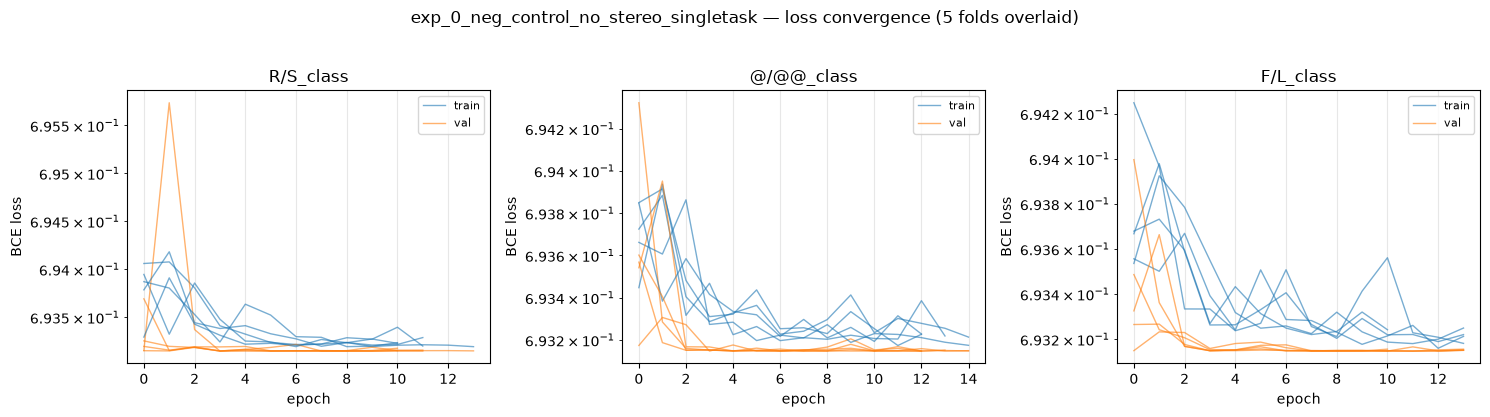

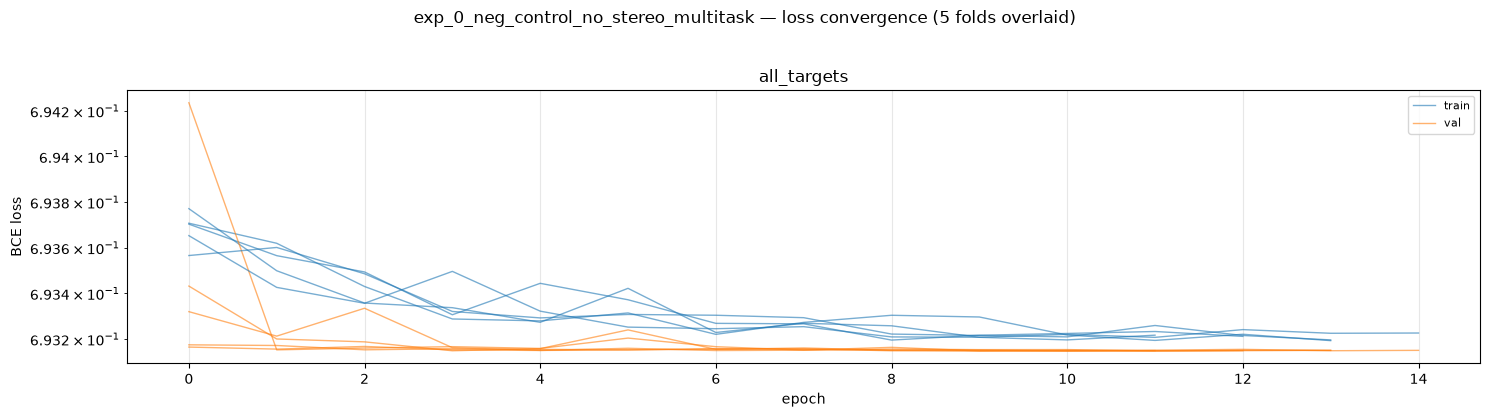

In [17]:
import matplotlib.pyplot as plt

def plot_loss_curves(curves_df, condition, figsize=(15, 4)):
    """Train vs. validation BCE per epoch, one panel per target, folds overlaid."""
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        for fold, g in t.groupby('fold'):
            g = g.sort_values('epoch')
            ax.plot(g['epoch'], g['train_loss_epoch'], alpha=.6, lw=1,
                    color='tab:blue', label='train' if fold == 0 else None)
            ax.plot(g['epoch'], g['val_loss'], alpha=.6, lw=1,
                    color='tab:orange', label='val' if fold == 0 else None)
        ax.set_title(f'{target}')
        ax.set_xlabel('epoch')
        ax.set_ylabel('BCE loss')
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    n_folds = sub['fold'].nunique()
    fig.suptitle(f'{condition} — loss convergence ({n_folds} '
                 f"fold{'s' if n_folds != 1 else ''} overlaid)", y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_loss_curves(curves_df, cond)
    plt.show()

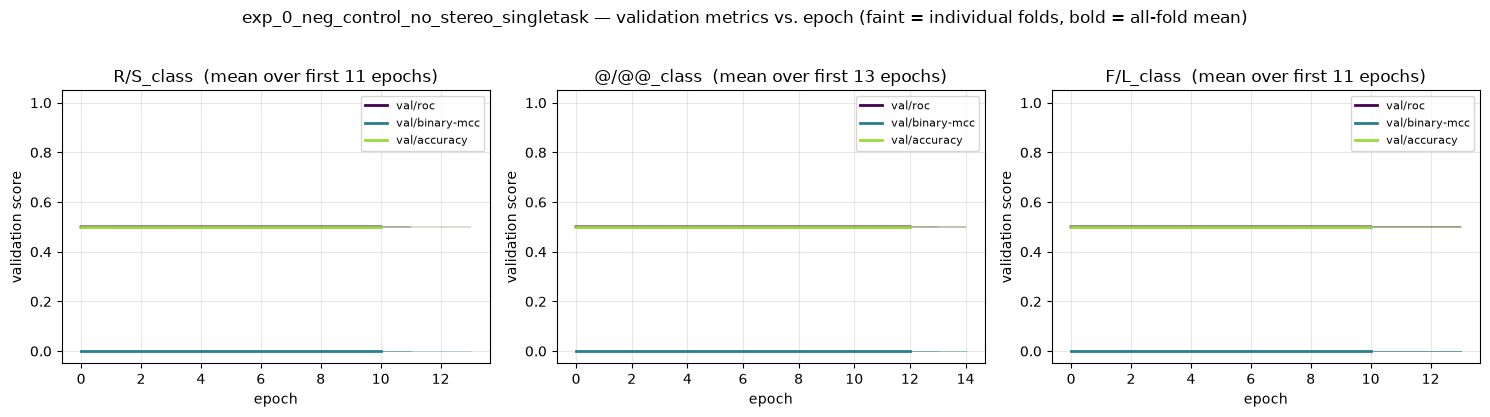

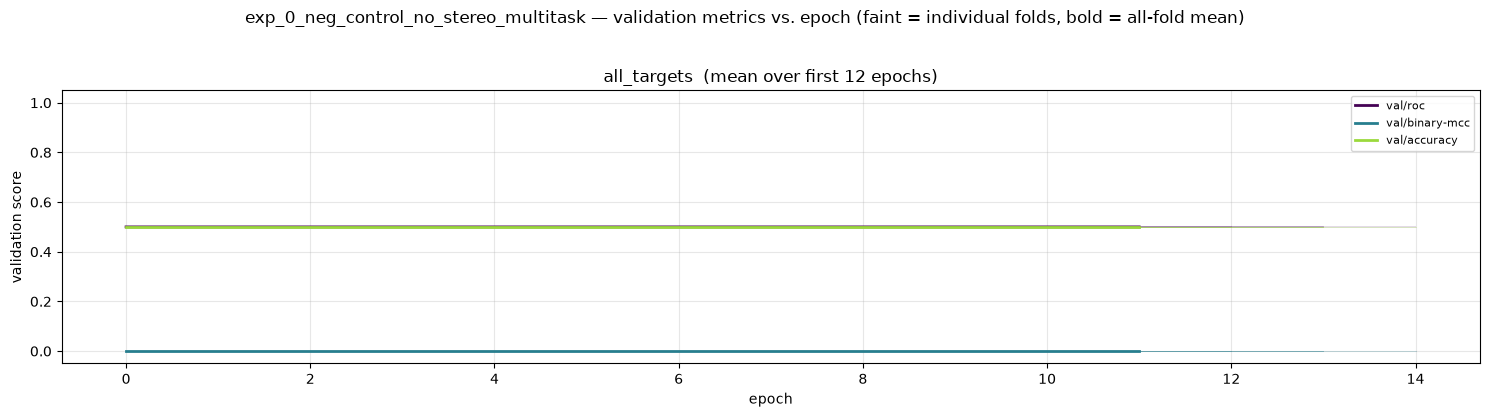

In [18]:
def _fold_mean(t, cols):
    """
    Fold-average `cols` per epoch, but only over epochs where EVERY fold is still training.

    Folds stop at different epochs, so a naive groupby('epoch').mean() silently averages
    over a shrinking subset: the tail of the curve would describe a different (and
    increasingly lucky) population than the head. Returns the complete-fold mean plus the
    fold count so callers can label what was dropped.
    """
    n_per_epoch = t.groupby('epoch')['fold'].nunique()
    n_folds = int(n_per_epoch.max())
    complete = n_per_epoch[n_per_epoch == n_folds].index
    return t[t['epoch'].isin(complete)].groupby('epoch')[cols].mean(), n_folds, len(n_per_epoch) - len(complete)


def plot_metric_curves(curves_df, condition, metrics=('val/roc', 'val/binary-mcc', 'val/accuracy'),
                       figsize=(15, 4)):
    """
    Validation metrics per epoch.

    Mind the mixed semantics of these three curves:
      * `val/roc` is threshold-free.
      * `val/accuracy` is thresholded at 0.5 by torchmetrics.
      * `val/binary-mcc` is NOT thresholded at all — chemprop's BinaryMCCMetric accumulates
        soft confusion counts straight from the probabilities, making it sensitive to
        confidence as well as ranking.
    None of them are comparable to the tuned-threshold metrics in the results CSV.

    Individual folds are drawn faintly; the bold line is the mean over epochs where all
    folds are still training (see `_fold_mean`).
    """
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)
    colors = plt.cm.viridis(np.linspace(0, .85, len(metrics)))

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        present = [m for m in metrics if m in t.columns]
        mean_df, n_folds, n_dropped = _fold_mean(t, present)
        for metric, color in zip(present, colors):
            for _, g in t.groupby('fold'):          # per-fold, faint
                g = g.sort_values('epoch')
                ax.plot(g['epoch'], g[metric], color=color, lw=.7, alpha=.25)
            ax.plot(mean_df.index, mean_df[metric], color=color, lw=2.0, label=metric)
        ax.set_title(f'{target}' + (f'  (mean over first {len(mean_df)} epochs)' if n_dropped else ''))
        ax.set_xlabel('epoch')
        ax.set_ylabel('validation score')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    fig.suptitle(f'{condition} — validation metrics vs. epoch '
                 f'(faint = individual folds, bold = all-fold mean)', y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_metric_curves(curves_df, cond)
    plt.show()